# EEG Emotion Classification — Baseline: Random Forest & SVM

Modelli classici di machine learning addestrati sulle **580 feature** (DE + DASM + RASM) per classificare le 5 emozioni target.

- **Random Forest** (300 alberi, `class_weight='balanced'`) — robusto alle feature irrilevanti, nessuna normalizzazione richiesta in teoria ma applicata per coerenza.
- **SVM RBF** (`C=10`, `gamma='scale'`) — kernel non lineare classico per EEG emotion recognition; sensibile alla scala, quindi richiede normalizzazione.

> Prerequisito: `Preprocessing.ipynb` (genera gli split in `data/splitted/`).

> ⚠️ **Stesso caveat della CNN**: lo split casuale stratificato lascia gli stessi 3 pazienti in train, val e test. Accuracy ~80–90 % qui è compatibile con subject-fingerprinting. La sezione LOSO fornisce la stima cross-soggetto onesta.

In [1]:
# ==========================================
# IMPORTS & SETUP
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)

EMOTION_LABELS = ['Disgust', 'Fear', 'Sad', 'Neutral', 'Happy']
NUM_CLASSES    = 5

## 1. Caricamento dati

Carichiamo i tre split precomputed da `data/splitted/` (`eeg_train.csv`, `eeg_val.csv`, `eeg_test.csv`).

Tutte le 580 feature (DE + DASM + RASM) vengono usate come vettore flat. Il `StandardScaler` viene fittato **solo sul training set** e applicato a val e test per evitare data leakage.

Lo split **70 / 15 / 15** è già stato applicato in `Preprocessing.ipynb` con stratificazione e `random_state=42`.

In [2]:
# ==========================================
# 1. CARICAMENTO DA SPLIT PRECOMPUTED (data/splitted/)
# ==========================================
SPLIT_DIR = '../data/splitted/'

df_train = pd.read_csv(SPLIT_DIR + 'eeg_train.csv')
df_val   = pd.read_csv(SPLIT_DIR + 'eeg_val.csv')
df_test  = pd.read_csv(SPLIT_DIR + 'eeg_test.csv')

FEAT_COLS = [c for c in df_train.columns if c.startswith(('DE_', 'DASM_', 'RASM_'))]
print(f'Feature totali: {len(FEAT_COLS)}')
print(f'Train: {df_train.shape}  |  Val: {df_val.shape}  |  Test: {df_test.shape}')

X_train_raw = df_train[FEAT_COLS].values.astype(np.float32)
y_train     = df_train['Label'].values.astype(int)

X_val_raw   = df_val[FEAT_COLS].values.astype(np.float32)
y_val       = df_val['Label'].values.astype(int)

X_test_raw  = df_test[FEAT_COLS].values.astype(np.float32)
y_test      = df_test['Label'].values.astype(int)

# StandardScaler fit su train, applicato a val e test
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

# df5 per la sezione LOSO (feature grezze non normalizzate)
df5 = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f'\nTrain: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')
print(f'Distribuzione classi train: {np.bincount(y_train)}')

Feature totali: 580
Train: (9374, 584)  |  Val: (2009, 584)  |  Test: (2009, 584)

Train: (9374, 580)  |  Val: (2009, 580)  |  Test: (2009, 580)
Distribuzione classi train: [1330 1897 2489 2069 1589]


## 2. Random Forest

`RandomForestClassifier` con 300 alberi addestrato sulle 580 feature normalizzate.

| Parametro | Valore | Motivazione |
|-----------|--------|-------------|
| `n_estimators` | 300 | buon compromesso bias/varianza su dati di questa dimensione |
| `class_weight` | `'balanced'` | compensa lo sbilanciamento tra classi (Sad >> Happy) |
| `n_jobs` | -1 | parallelizzazione su tutti i core disponibili |

Addestramento Random Forest...
Completato.

Random Forest — Val Accuracy : 85.96%
Random Forest — Test Accuracy: 85.86%

--- Test set report ---
              precision    recall  f1-score   support

     Disgust      0.882     0.684     0.771       285
        Fear      0.882     0.811     0.845       407
         Sad      0.820     0.914     0.864       533
     Neutral      0.842     0.905     0.873       443
       Happy      0.907     0.915     0.911       341

    accuracy                          0.859      2009
   macro avg      0.867     0.846     0.853      2009
weighted avg      0.861     0.859     0.857      2009



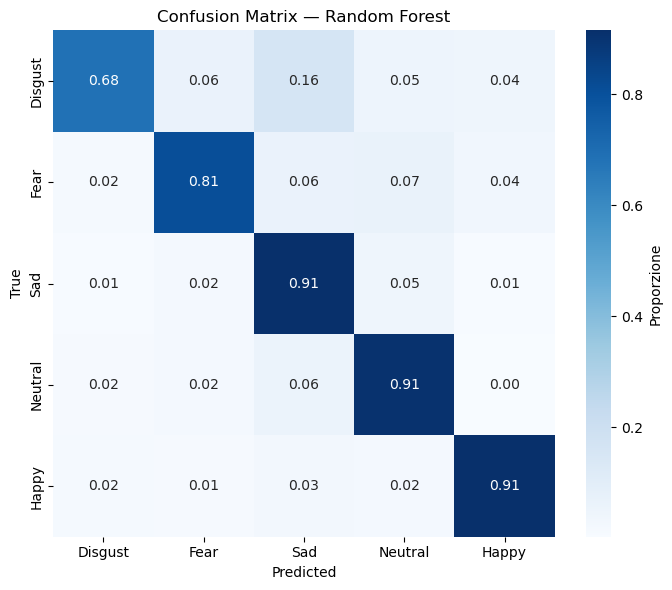

In [3]:
# ==========================================
# 2.1 Training
# ==========================================
print('Addestramento Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
print('Completato.')

# ==========================================
# 2.2 Val + Test evaluation
# ==========================================
y_val_pred_rf  = rf.predict(X_val)
y_test_pred_rf = rf.predict(X_test)

print(f'\nRandom Forest — Val Accuracy : {(y_val_pred_rf == y_val).mean() * 100:.2f}%')
print(f'Random Forest — Test Accuracy: {(y_test_pred_rf == y_test).mean() * 100:.2f}%\n')

print('--- Test set report ---')
print(classification_report(y_test, y_test_pred_rf, target_names=EMOTION_LABELS, digits=3))

# ==========================================
# 2.3 Confusion Matrix
# ==========================================
cm_rf = confusion_matrix(y_test, y_test_pred_rf, normalize='true')
plt.figure(figsize=(7, 6))
sns.heatmap(cm_rf, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            cbar_kws={'label': 'Proporzione'})
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

## 3. SVM (RBF kernel)

`SVC` con kernel RBF, scelta classica per classificazione EEG-based emotion recognition.

| Parametro | Valore | Motivazione |
|-----------|--------|-------------|
| `kernel` | `'rbf'` | cattura non-linearità inter-banda/canale residue dopo la DE |
| `C` | 10 | margine morbido con penalizzazione moderata degli errori |
| `gamma` | `'scale'` | scala automatica = `1 / (n_features * X.var())` |
| `class_weight` | `'balanced'` | stesso bilanciamento di RF |

> Il training SVM su ~9000 campioni con kernel RBF può richiedere alcuni minuti.

Addestramento SVM (RBF) — puo richiedere alcuni minuti...
Completato.

SVM — Val Accuracy : 85.52%
SVM — Test Accuracy: 86.41%

--- Test set report ---
              precision    recall  f1-score   support

     Disgust      0.751     0.804     0.776       285
        Fear      0.851     0.828     0.839       407
         Sad      0.871     0.850     0.860       533
     Neutral      0.903     0.907     0.905       443
       Happy      0.918     0.924     0.921       341

    accuracy                          0.864      2009
   macro avg      0.859     0.863     0.860      2009
weighted avg      0.865     0.864     0.864      2009



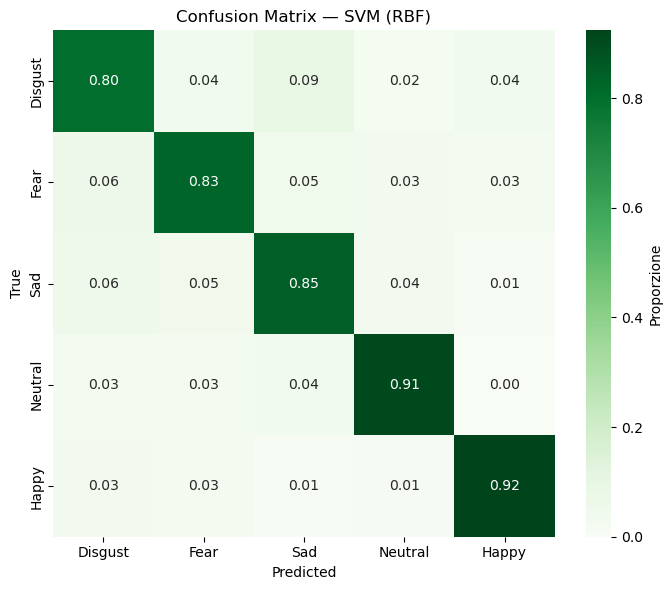

In [4]:
# ==========================================
# 3.1 Training
# ==========================================
print('Addestramento SVM (RBF) — puo richiedere alcuni minuti...')
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
print('Completato.')

# ==========================================
# 3.2 Val + Test evaluation
# ==========================================
y_val_pred_svm  = svm.predict(X_val)
y_test_pred_svm = svm.predict(X_test)

print(f'\nSVM — Val Accuracy : {(y_val_pred_svm == y_val).mean() * 100:.2f}%')
print(f'SVM — Test Accuracy: {(y_test_pred_svm == y_test).mean() * 100:.2f}%\n')

print('--- Test set report ---')
print(classification_report(y_test, y_test_pred_svm, target_names=EMOTION_LABELS, digits=3))

# ==========================================
# 3.3 Confusion Matrix
# ==========================================
cm_svm = confusion_matrix(y_test, y_test_pred_svm, normalize='true')
plt.figure(figsize=(7, 6))
sns.heatmap(cm_svm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            cbar_kws={'label': 'Proporzione'})
plt.title('Confusion Matrix — SVM (RBF)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

## 4. Leave-One-Subject-Out (LOSO)

Protocollo di valutazione **cross-soggetto** onesto: con soli 3 pazienti usiamo `GroupKFold(n_splits=3)`, che in ogni fold lascia fuori un paziente intero come test set e addestra sui restanti due.

Per eliminare gli offset di ampiezza inter-soggetto, un nuovo `StandardScaler` viene fittato **esclusivamente sui dati di training** di quel fold e poi applicato al test set.

> Come per la CNN, ci aspettiamo un'accuracy LOSO molto più bassa (~25–40 %) rispetto allo split casuale, poiché il modello non può appoggiarsi alla firma neurale del soggetto tenuto fuori.


--- Fold 1  |  soggetto tenuto fuori: [3] ---
RF  Accuracy fold 1: 35.49%
              precision    recall  f1-score   support

     Disgust      0.600     0.004     0.007       823
        Fear      0.187     0.026     0.046      1002
         Sad      0.283     0.512     0.365      1277
     Neutral      0.331     0.598     0.426       985
       Happy      0.700     0.575     0.631       810

    accuracy                          0.355      4897
   macro avg      0.420     0.343     0.295      4897
weighted avg      0.395     0.355     0.296      4897



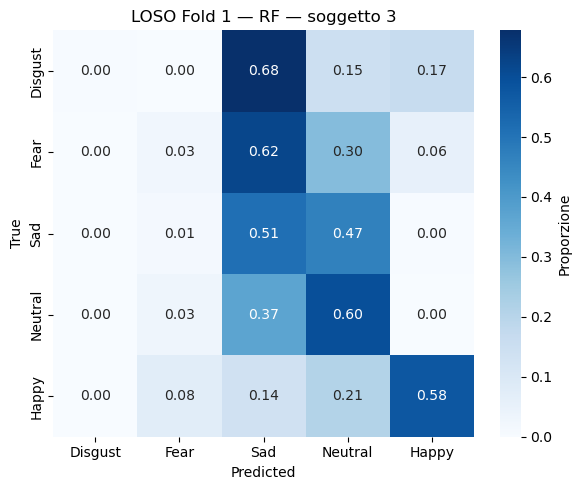

Addestramento SVM fold 1...
SVM Accuracy fold 1: 30.88%
              precision    recall  f1-score   support

     Disgust      0.237     0.091     0.132       823
        Fear      0.192     0.066     0.098      1002
         Sad      0.248     0.453     0.320      1277
     Neutral      0.309     0.464     0.371       985
       Happy      0.792     0.415     0.545       810

    accuracy                          0.309      4897
   macro avg      0.356     0.298     0.293      4897
weighted avg      0.337     0.309     0.290      4897



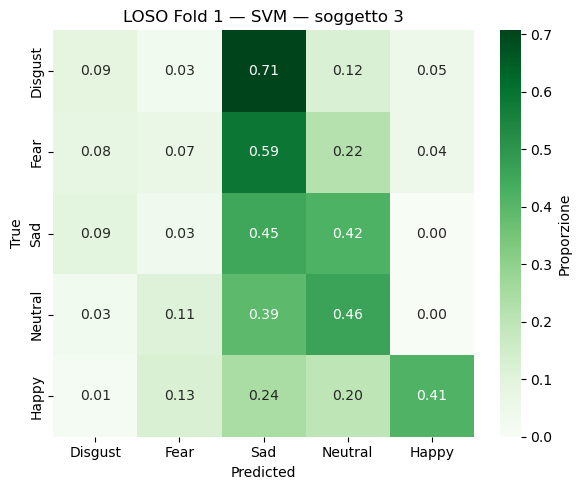


--- Fold 2  |  soggetto tenuto fuori: [2] ---
RF  Accuracy fold 2: 33.32%
              precision    recall  f1-score   support

     Disgust      0.114     0.165     0.135       599
        Fear      0.333     0.009     0.018       876
         Sad      0.323     0.731     0.448      1277
     Neutral      0.471     0.191     0.272       985
       Happy      0.780     0.354     0.487       810

    accuracy                          0.333      4547
   macro avg      0.404     0.290     0.272      4547
weighted avg      0.411     0.333     0.293      4547



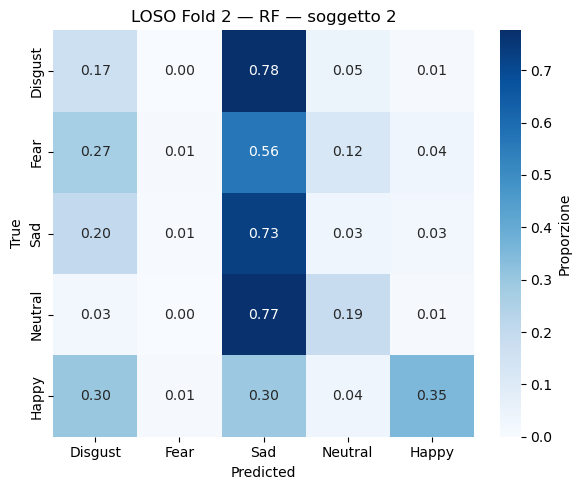

Addestramento SVM fold 2...
SVM Accuracy fold 2: 29.29%
              precision    recall  f1-score   support

     Disgust      0.155     0.164     0.159       599
        Fear      0.040     0.005     0.008       876
         Sad      0.398     0.124     0.189      1277
     Neutral      0.255     0.791     0.385       985
       Happy      0.825     0.362     0.503       810

    accuracy                          0.293      4547
   macro avg      0.334     0.289     0.249      4547
weighted avg      0.342     0.293     0.249      4547



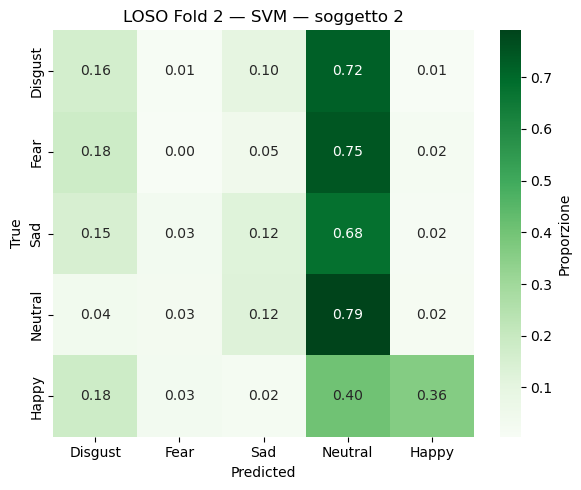


--- Fold 3  |  soggetto tenuto fuori: [1] ---
RF  Accuracy fold 3: 28.34%
              precision    recall  f1-score   support

     Disgust      0.185     0.241     0.209       478
        Fear      0.270     0.133     0.178       833
         Sad      0.327     0.306     0.316      1001
     Neutral      0.364     0.004     0.008       985
       Happy      0.296     0.896     0.445       651

    accuracy                          0.283      3948
   macro avg      0.288     0.316     0.231      3948
weighted avg      0.302     0.283     0.218      3948



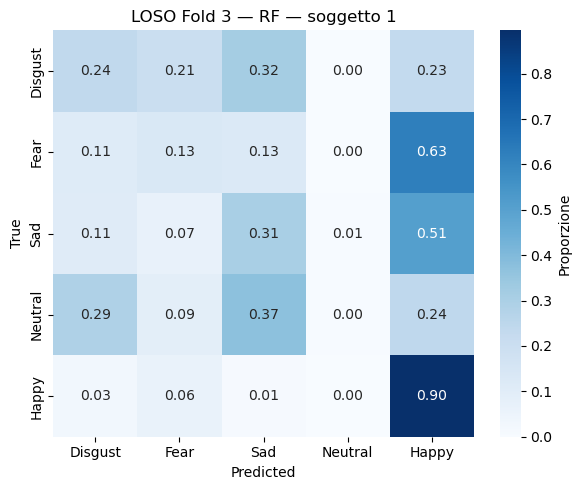

Addestramento SVM fold 3...
SVM Accuracy fold 3: 26.75%
              precision    recall  f1-score   support

     Disgust      0.185     0.410     0.255       478
        Fear      0.160     0.094     0.118       833
         Sad      0.263     0.316     0.287      1001
     Neutral      0.467     0.051     0.092       985
       Happy      0.380     0.639     0.476       651

    accuracy                          0.267      3948
   macro avg      0.291     0.302     0.246      3948
weighted avg      0.302     0.267     0.230      3948



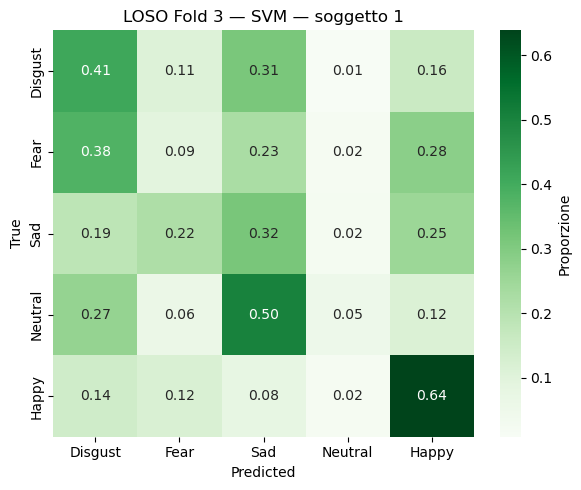


LOSO — Riepilogo Baseline
  RF  — Accuracy per fold: ['35.49%', '33.32%', '28.34%']
  RF  — Media +/- std    : 32.38% +/- 2.99%
  SVM — Accuracy per fold: ['30.88%', '29.29%', '26.75%']
  SVM — Media +/- std    : 28.97% +/- 1.70%


In [5]:
# ==========================================
# 4. LEAVE-ONE-SUBJECT-OUT (LOSO)
# ==========================================
groups    = df5['Patient_ID'].values
X_all     = df5[FEAT_COLS].values.astype(np.float32)
y_lbl_all = df5['Label'].values.astype(int)

gkf = GroupKFold(n_splits=3)
loso_accs_rf  = []
loso_accs_svm = []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_all, y_lbl_all, groups)):
    held_out = np.unique(groups[test_idx])
    print(f'\n--- Fold {fold_idx + 1}  |  soggetto tenuto fuori: {held_out} ---')

    X_tr_raw = X_all[train_idx]
    X_te_raw = X_all[test_idx]
    y_tr     = y_lbl_all[train_idx]
    y_te     = y_lbl_all[test_idx]

    # Normalizzazione: fit su train di questo fold, apply su test
    scaler_fold = StandardScaler()
    X_tr_sc = scaler_fold.fit_transform(X_tr_raw)
    X_te_sc = scaler_fold.transform(X_te_raw)

    # --- Random Forest ---
    rf_fold = RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_fold.fit(X_tr_sc, y_tr)
    y_pred_rf_fold = rf_fold.predict(X_te_sc)
    acc_rf = (y_pred_rf_fold == y_te).mean()
    loso_accs_rf.append(acc_rf)

    print(f'RF  Accuracy fold {fold_idx + 1}: {acc_rf * 100:.2f}%')
    print(classification_report(y_te, y_pred_rf_fold,
                                target_names=EMOTION_LABELS, digits=3, zero_division=0))

    cm_rf_loso = confusion_matrix(y_te, y_pred_rf_fold, normalize='true')
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_rf_loso, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                cbar_kws={'label': 'Proporzione'})
    plt.title(f'LOSO Fold {fold_idx + 1} — RF — soggetto {held_out[0]}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

    # --- SVM ---
    print(f'Addestramento SVM fold {fold_idx + 1}...')
    svm_fold = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42)
    svm_fold.fit(X_tr_sc, y_tr)
    y_pred_svm_fold = svm_fold.predict(X_te_sc)
    acc_svm = (y_pred_svm_fold == y_te).mean()
    loso_accs_svm.append(acc_svm)

    print(f'SVM Accuracy fold {fold_idx + 1}: {acc_svm * 100:.2f}%')
    print(classification_report(y_te, y_pred_svm_fold,
                                target_names=EMOTION_LABELS, digits=3, zero_division=0))

    cm_svm_loso = confusion_matrix(y_te, y_pred_svm_fold, normalize='true')
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_svm_loso, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                cbar_kws={'label': 'Proporzione'})
    plt.title(f'LOSO Fold {fold_idx + 1} — SVM — soggetto {held_out[0]}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

print('\n' + '='*50)
print('LOSO — Riepilogo Baseline')
print(f'  RF  — Accuracy per fold: {[f"{a*100:.2f}%" for a in loso_accs_rf]}')
print(f'  RF  — Media +/- std    : {np.mean(loso_accs_rf)*100:.2f}% +/- {np.std(loso_accs_rf)*100:.2f}%')
print(f'  SVM — Accuracy per fold: {[f"{a*100:.2f}%" for a in loso_accs_svm]}')
print(f'  SVM — Media +/- std    : {np.mean(loso_accs_svm)*100:.2f}% +/- {np.std(loso_accs_svm)*100:.2f}%')
print('='*50)